In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop_duplicates()

print("Data ready!", df.shape)

Data ready! (891, 11)


In [2]:
# Basic statistics
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:")
df.describe()

Shape: (891, 11)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


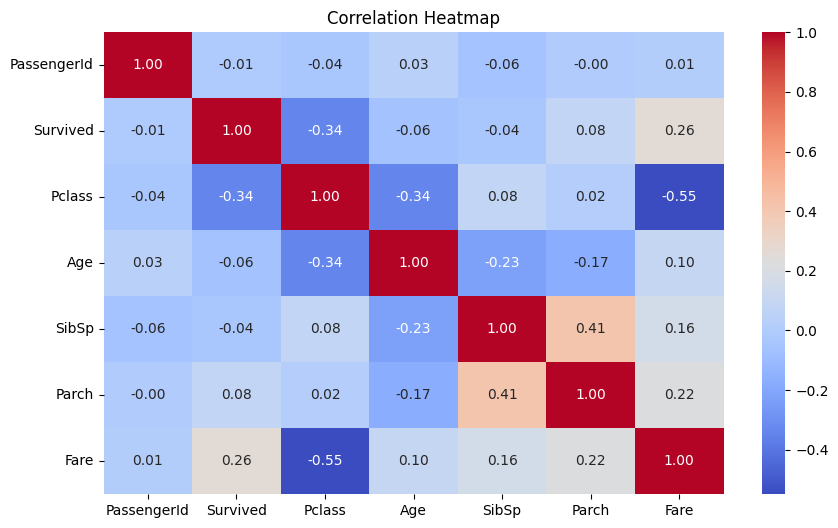

In [3]:
# Correlation between all number columns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [4]:
print("Overall Survival Rate:")
print(df['Survived'].value_counts(normalize=True) * 100)

print("\nSurvival Rate by Gender:")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\nSurvival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

Overall Survival Rate:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
